<a href="https://colab.research.google.com/github/Annette-1/Ecuaciones_Diferenciales_Parciales/blob/main/TIBISA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <span style="color:teal;">**Ejercicio de TIBISA**</span>
<span style="color:purple;"></span>

Resolver por simulación a detalle, utilizando la metodología propuesta en el curso.

La empresa TIBASA (Fabricante de tinas de baño) tiene asignado un camión especial para el transporte de tinas terminadas. Dicho camión transporta diariamente 5 tinas. El peso de cada tina sigue la distribución triangular de la imagen anexa.

Si la capacidad del camión es de 1 tonelada, **¿cuál es la probabilidad de que el peso de las tinas exceda la capacidad del camión?**

Observando la gráfica vemos que sigue una distribución triangular

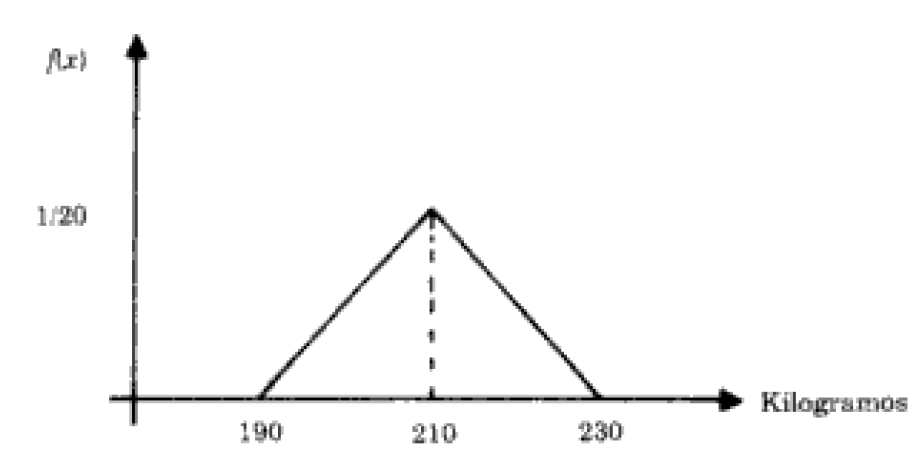


Aplicando la metodología tenemos:
* <span style="color:teal;">**Paso 1.** Identificamos las variables </span>

En este caso son:

* Peso de las tinas: $X_1,X_2,X_3,X_4,X_5$
donde
$X ∼ triangular$($a$=190kg , $b$=230kg, $c$=210kg)

Necesitamos la **suma**
 $S=X_1,X_2,X_3,X_4,X_5$

*  <span style="color:teal;">**Paso 2.** Determine la distribución de probabilidad</span>
Sigue una distribución:

$X ∼ triangular$($a$=190kg , $b$=230kg, $c$=210kg)

*  <span style="color:teal;">**Paso 3** y **Paso 4** </span>
Nose tomara en cuenta dado que no hay tabla de frecuencias nos pasamos directamente al **paso 6**

* <span style="color:teal;">**Paso 6**  Simulación </span>
Repita el experimento $n$ veces

El modelo para este Problema es:
$$S≤1000kg(1 \quad tonelada)$$

In [51]:
import random as r
import numpy as np
import matplotlib.pyplot as plt

Definimos los Parámetros

In [52]:
# Parámetros de la distribución triangular
a = 190   # mínimo (kg)
c = 210   # moda (kg)
b = 230   # máximo (kg)
capacidad = 1000  #  kg (1 tonelada)
n_tinas = 5        # número de tinas por viaje
n_simulaciones = 100000


Usamos el método de la Transformada Inversa basado en fórmula estándar:

Para triangular(a, b, c):

Si $U \sim \text{Uniform}(0,1) $:
  
Sea  
$$
F_c = \frac{c-a}{b-a}.
$$
Si $ U \le F_c $:
$$
X = a + \sqrt{U(b-a)(c-a)}
$$
Sino:
$$
X = b - \sqrt{(1-U)(b-a)(b-c)}.
$$


In [53]:
# Función para generar una variable triangular
def triangular(a, b, c):
    """Genera un valor de distribución triangular(a,b,c)"""
    u = r.random()  # uniforme [0,1]
    F_c = (c - a) / (b - a)
    if u <= F_c:
        return a + np.sqrt(u * (b - a) * (c - a))
    else:
        return b - np.sqrt((1 - u) * (b - a) * (b - c))

In [54]:
triangular(a, b, c)

np.float64(199.75375087802087)

PASO 8. Replique el modelo para n simulaciones

In [55]:
# Simulación
pesos_totales = []
for _ in range(n_simulaciones):
    # Generar 5 tinas y sumar sus pesos
    viaje = sum(triangular(a, b, c) for _ in range(n_tinas))
    pesos_totales.append(viaje)

In [56]:
viaje

np.float64(1061.7572151674506)

Vamos a calcular la probabilidad del peso total

In [57]:
# Calcular probabilidad
pesos_totales = np.array(pesos_totales)
prob_exceso = np.mean(pesos_totales > capacidad)

In [58]:
print(f"=== RESULTADOS ===")
print(f"Simulaciones: {n_simulaciones:,}")
print(f"Probabilidad de exceder {capacidad} kg: {prob_exceso:.6f}")
print(f"Porcentaje: {prob_exceso*100:.4f}%")
print(f"Media del peso total: {pesos_totales.mean():.2f} kg") #Calculo de la media
print(f"Desviación estándar: {pesos_totales.std():.2f} kg")

=== RESULTADOS ===
Simulaciones: 100,000
Probabilidad de exceder 1000 kg: 0.997320
Porcentaje: 99.7320%
Media del peso total: 1049.89 kg
Desviación estándar: 18.29 kg


Graficamos las simulaciones del modelo

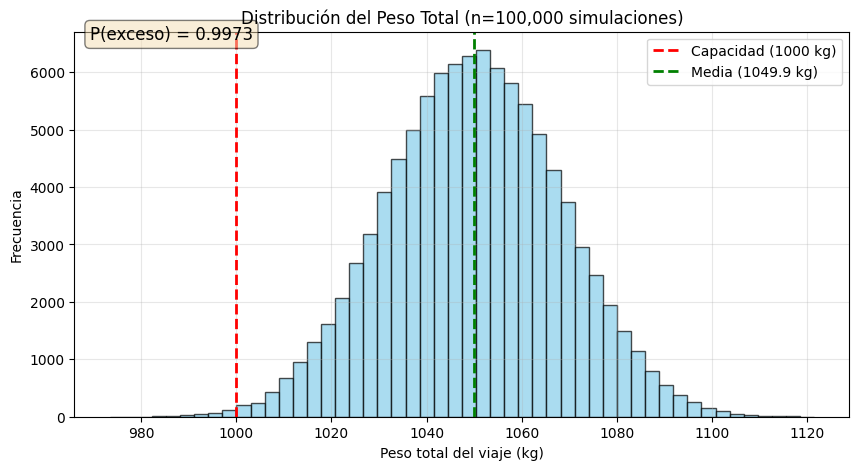

In [59]:
# Gráfico
plt.figure(figsize=(10, 5))
plt.hist(pesos_totales, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.axvline(capacidad, color='red', linestyle='--', linewidth=2, label=f'Capacidad ({capacidad} kg)')
plt.axvline(pesos_totales.mean(), color='green', linestyle='--', linewidth=2, label=f'Media ({pesos_totales.mean():.1f} kg)')
plt.xlabel('Peso total del viaje (kg)')
plt.ylabel('Frecuencia')
plt.title(f'Distribución del Peso Total (n={n_simulaciones:,} simulaciones)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.text(0.02, 0.98, f'P(exceso) = {prob_exceso:.4f}',
         transform=plt.gca().transAxes, fontsize=12,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.show()

## <span style="color:purple;">**Conclusión**</span>
La probabilidad de exceder la capacidad del camión es del **$\boxed{\% 99.76}$** lo cual es casi seguro; pero si simularamos 4 tinas en vez de 5 la probabildad seria del **%0** lo cual sería recomendable reducir a 4 tinas por viaje.

Como mostramos a continuación:

In [60]:
# Conclusión
if prob_exceso > 0.5:
    # Simular con 4 tinas
    pesos_4 = [sum(triangular(a, b, c) for _ in range(4)) for _ in range(n_simulaciones)]
    prob_4 = np.mean(np.array(pesos_4) > capacidad)
    print(f"→ Con 4 tinas: probabilidad = {prob_4:.6f} ({prob_4*100:.4f}%)")

→ Con 4 tinas: probabilidad = 0.000000 (0.0000%)


### <span style="color:purple;">**Solución Analítica**</span>

Sea $X$ el peso de una tina (en kg) con distribución triangular:
$$
X \sim \text{Triangular}(a=190,\ b=230,\ c=210)
$$

Función de densidad de probabilidad:
$$
f_X(x) =
\begin{cases}
\dfrac{2(x-a)}{(b-a)(c-a)}, & a \leq x \leq c \\[1em]
\dfrac{2(b-x)}{(b-a)(b-c)}, & c \leq x \leq b \\[1em]
0, & \text{otro caso}
\end{cases}
$$

Reemplazando valores:
$$
f_X(x) =
\begin{cases}
\dfrac{2(x-190)}{40 \cdot 20} = \dfrac{x-190}{400}, & 190 \leq x \leq 210 \\[1em]
\dfrac{2(230-x)}{40 \cdot 20} = \dfrac{230-x}{400}, & 210 \leq x \leq 230 \\[1em]
0, & \text{otro caso}
\end{cases}
$$

### Parámetros de la Distribución

* Media
$$
\mu_X = \frac{a+b+c}{3} = \frac{190+230+210}{3} = \frac{630}{3} = 210 \text{ kg}
$$

* Varianza
$$
\sigma_X^2 = \frac{a^2+b^2+c^2 - ab - ac - bc}{18}
$$
$$
\sigma_X^2 = \frac{190^2+230^2+210^2 - 190\cdot230 - 190\cdot210 - 230\cdot210}{18}
$$
$$
\sigma_X^2 = \frac{36100+52900+44100 - 43700 - 39900 - 48300}{18}
$$
$$
\sigma_X^2 = \frac{133100 - 131900}{18} = \frac{1200}{18} = \frac{200}{3} \approx 66.67
$$
$$
\sigma_X = \sqrt{\frac{200}{3}} \approx 8.165 \text{ kg}
$$

* Sumando las  5 Tinas

Sea $S = X_1 + X_2 + X_3 + X_4 + X_5$ donde $X_i \sim \text{Triangular}(190,230,210)$.

* Media de la suma
$$
\mu_S = 5\mu_X = 5 \cdot 210 = 1050 \text{ kg}
$$

* Varianza de la suma
$$
\sigma_S^2 = 5\sigma_X^2 = 5 \cdot \frac{200}{3} = \frac{1000}{3} \approx 333.33
$$
$$
\sigma_S = \sqrt{\frac{1000}{3}} \approx 18.257 \text{ kg}
$$

* **Probabilidad de Exceder la Capacidad**

Capacidad del camión: $C = 1000$ kg

Buscamos:
$$
P(S > 1000) = 1 - P(S \leq 1000)
$$

**Aproximación por el Teorema Central del Límite**

Por el TCL, para $n=5$:
$$
\frac{S - \mu_S}{\sigma_S} \approx Z \sim N(0,1)
$$

Entonces:
$$
P(S > 1000) = P\left( Z > \frac{1000 - 1050}{18.257} \right)
$$
$$
P(S > 1000) = P\left( Z > -2.738 \right)
$$
$$
P(S > 1000) = 1 - \Phi(-2.738) = \Phi(2.738)
$$

Usando tablas de la normal estándar:
$$
\Phi(2.74) \approx 0.99693
$$

Por lo tanto:
$$
P(S > 1000) \approx 0.9969 \quad \text{(99.69\%)}
$$


* Resultados Comparativos

$
\boxed{
\begin{array}{lc}
\text{Método} & P(S > 1000) \\
\hline
\text{Teorema Central del Límite} & 0.9969 \\
\text{Simulación} & 0.9976 \\
\end{array}
}
$

## **Conclusión**

La probabilidad de que el peso de 5 tinas exceda la capacidad de 1 tonelada es aproximadamente:

$
\boxed{P(S > 1000) \approx 0.999}
$

Es decir, hay un $99.9\%$ de probabilidad de que el camión se sobrecargue si transporta 5 tinas diariamente.

Por lo cual seria recomnedable reducir el riesgo, sería factible transportar solo 4 tinas por viaje. Lo cual con 4 tinas:
$$
\mu_{S_4} = 4 \cdot 210 = 840 \text{ kg}
$$
$$
\sigma_{S_4} = \sqrt{4} \cdot 8.165 = 16.33 \text{ kg}
$$
$$
P(S_4 > 1000) = P\left( Z > \frac{1000-840}{16.33} \right) = P(Z > 9.80) \approx 0
$$


###

<span style="color:purple;"></span>